NOte-1:

    - en Risk modeling se baser sur des correlation ne permet pas de capturer les interactions non lineaire entre les variables
    - Pour faire une selection de feature on se base sur le Weight of Evidence + information value

NOte-2:

    - On rencontre aussi le Probleme du imbalanced dataset en credit risk , il faut donc trouver une solution de sampling
    - choisir les bon metric pour evaluer le model en occurrence ( AUC , Gini )

In [1]:

from src.pipelines.Feature.fearurePipline import FeaturePipline

import seaborn as sns


import pandas as pd

# recuperation des variable non correle
dataset = pd.read_csv('/Users/macbookpro/PycharmProjects/projet_credit_risk_modeling/data/processed/credit_risk_cleansed_dataset_v0.csv')


df = dataset.copy()
df.drop(columns = 'age_groupe', inplace = True)



(CVXPY) May 25 04:38:56 AM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) May 25 04:38:56 AM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


# Split-Train/validation/test

In [3]:
from sklearn.model_selection import train_test_split

In [2]:
# separation Target-feature

x = df.drop('loan_status', axis=1)
y = df['loan_status']

In [4]:
x.shape

(31833, 11)

In [4]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=42
)

test data

In [5]:
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [13]:
y_train.shape


(22283,)

In [12]:
x_train.shape

(22283, 11)

In [11]:
config = {
    "woe": {
        "iv_threshold": 0.02,
        "metric": "woe",
        "persistence": False
    },
    "smote": {
        "enabled": True
    },
    "correlation": {
        "threshold": 0.8
    }
}

In [14]:
featurePipline = FeaturePipline(x_train,y_train,state='run',config = config)
featurePipline.woe_iv_report

,IV
person_income,0.546891
person_home_ownership,0.375964
person_emp_length,0.057387
loan_intent,0.093081
loan_grade,0.860231
loan_amnt,0.103727
loan_int_rate,0.699679
loan_percent_income,0.965651
cb_person_default_on_file,0.161876
residual_income_proxy,0.784925


correlation before handling

In [17]:
featurePipline.woe_table['person_age']

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 22.50)",3242,0.145492,2403,839,0.258791,-0.228442,8.079013e-03,1.007686e-03
1,"[22.50, 23.50)",2652,0.119014,2067,585,0.220588,-0.018463,4.078055e-05,5.097496e-06
2,"[23.50, 26.50)",6179,0.277297,4835,1344,0.217511,-0.000474,6.220533e-08,7.775666e-09
3,"[26.50, 28.50)",2775,0.124534,2190,585,0.210811,0.03934,1.905953e-04,2.382288e-05
4,"[28.50, 31.50)",2845,0.127676,2275,570,0.200351,0.103394,1.325016e-03,1.655532e-04
5,"[31.50, 33.50)",1248,0.056007,1022,226,0.181090,0.228277,2.730564e-03,3.405814e-04
6,"[33.50, 38.50)",1886,0.084639,1502,384,0.203606,0.083206,5.721867e-04,7.150271e-05
7,"[38.50, inf)",1456,0.065341,1144,312,0.214286,0.018578,2.243481e-05,2.804311e-06
8,Special,0,0.000000,0,0,0.000000,0.0,0.000000e+00,0.000000e+00
9,Missing,0,0.000000,0,0,0.000000,0.0,0.000000e+00,0.000000e+00


In [12]:
featurePipline.woe.capturedFit.summary()

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
0,person_age,numerical,OPTIMAL,False,8,0.012961,0.001617,0.058174,0.001823
1,person_income,numerical,OPTIMAL,True,8,0.546891,0.064036,0.388167,0.343293
2,person_home_ownership,categorical,OPTIMAL,True,3,0.375964,0.045837,0.299588,0.705757
3,person_emp_length,numerical,OPTIMAL,True,7,0.057387,0.007146,0.134225,0.007895
4,loan_intent,categorical,OPTIMAL,True,6,0.093081,0.011565,0.167423,0.162082
5,loan_grade,categorical,OPTIMAL,True,4,0.860231,0.098159,0.443612,0.293919
6,loan_amnt,numerical,OPTIMAL,True,10,0.103727,0.012781,0.167041,0.1725
7,loan_int_rate,numerical,OPTIMAL,True,11,0.699679,0.080446,0.420279,0.128912
8,loan_percent_income,numerical,OPTIMAL,True,9,0.965651,0.105965,0.453357,0.065823
9,cb_person_default_on_file,categorical,OPTIMAL,True,2,0.161876,0.019846,0.164627,0.241665


<Axes: >

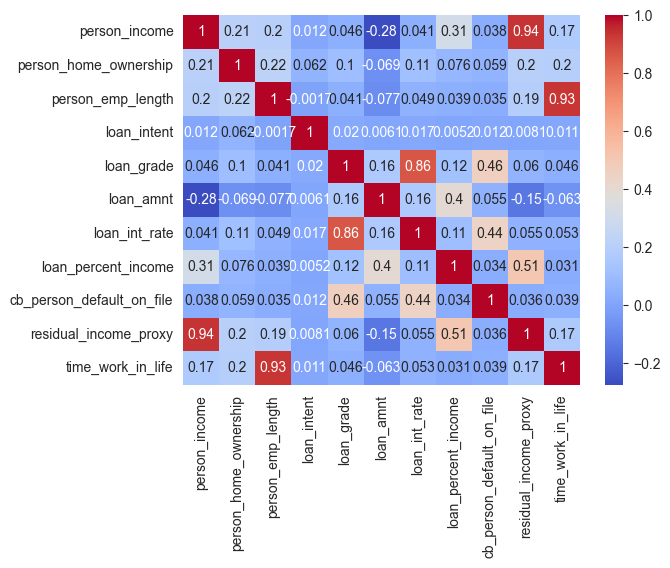

In [13]:
corr = featurePipline.correled
sns.heatmap(corr, annot=True,cmap='coolwarm')

transformation

Les donnees sont transformer et reeequilibre en cas de train

In [14]:
train_woe = featurePipline.transformed

In [6]:

x_train.to_csv('/Users/macbookpro/PycharmProjects/projet_credit_risk_modeling/data/processed/splited_data/x_train.csv',sep=',', index=False)
y_train.to_csv('/Users/macbookpro/PycharmProjects/projet_credit_risk_modeling/data/processed/splited_data/y_train.csv',sep=',', index=False)

x_val.to_csv('/Users/macbookpro/PycharmProjects/projet_credit_risk_modeling/data/processed/splited_data/x_val.csv',sep=',', index=False)
y_val.to_csv('/Users/macbookpro/PycharmProjects/projet_credit_risk_modeling/data/processed/splited_data/y_val.csv',sep=',', index=False)

x_test.to_csv('/Users/macbookpro/PycharmProjects/projet_credit_risk_modeling/data/processed/splited_data/x_test.csv',sep=',', index=False)
y_test.to_csv('/Users/macbookpro/PycharmProjects/projet_credit_risk_modeling/data/processed/splited_data/y_test.csv',sep=',', index=False)

